# conv_analytics_eval — Pipeline Diagram

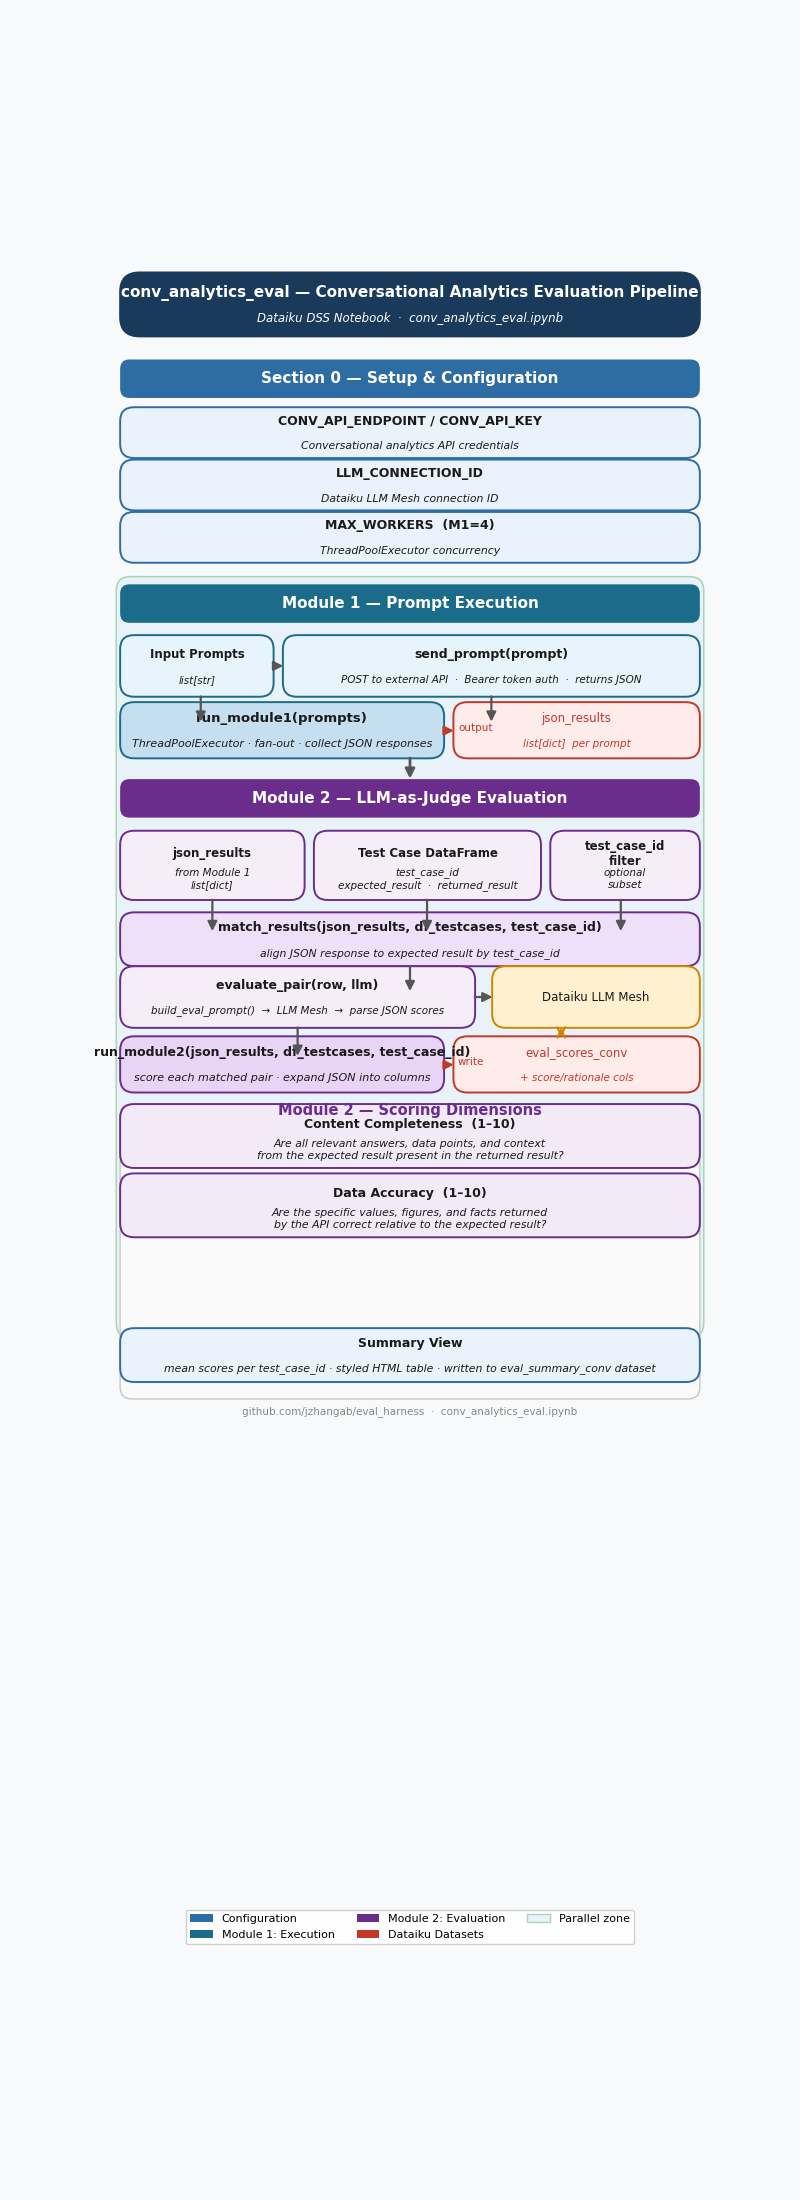


# conv_analytics_eval
**Conversational Analytics System — Evaluation Pipeline**

| Module | Purpose | Input | Output |
|--------|---------|-------|--------|
| 1 | Prompt Execution | `list[str]` of text prompts | `json_results` list + `conv_results` dataset |
| 2 | LLM-as-Judge Evaluation | `json_results`, test-case DataFrame, optional `test_case_id` filter | `eval_scores_conv` dataset |

**Parallelism:** Module 1 uses `ThreadPoolExecutor`. Module 2 runs sequentially by default to respect LLM Mesh rate limits.

---
## Section 0 — Setup & Configuration

In [ ]:
import os
import re
import json
import concurrent.futures

import requests
import pandas as pd
from IPython.display import display, HTML

import dataiku

# ---------------------------------------------------------------------------
# Configuration — edit before running
# ---------------------------------------------------------------------------

# Module 1: Conversational analytics API
CONV_API_ENDPOINT = os.environ.get("CONV_API_ENDPOINT", "https://<your-api-host>/v1/query")
CONV_API_KEY      = os.environ.get("CONV_API_KEY", "")   # set in Dataiku DSS secrets or env
API_TIMEOUT       = 60   # seconds per request

# Module 2: Dataiku LLM Mesh connection ID
LLM_CONNECTION_ID = os.environ.get("LLM_CONNECTION_ID", "openai:gpt-4o")

# Parallelism
MODULE1_WORKERS = 4   # parallel prompt API calls
MODULE2_WORKERS = 2   # set to 1 for strict sequential

print("Configuration loaded.")
print(f"  CONV_API_ENDPOINT : {CONV_API_ENDPOINT}")
print(f"  LLM_CONNECTION_ID : {LLM_CONNECTION_ID}")
print(f"  Workers (M1/M2)   : {MODULE1_WORKERS}/{MODULE2_WORKERS}")


---
## Module 1 — Prompt Execution

Sends each text prompt to the conversational analytics API in parallel and collects the JSON responses.

**Input:** `PROMPTS` — list of plain-text query strings.  
**Output:** `json_results` — list of dicts, one per prompt; also written to Dataiku dataset `conv_results`.

Each result dict contains:
```json
{ "prompt": "<original prompt>", "response": <API JSON>, "status": "success"|"error", "error": null }
```


In [ ]:
# ── Module 1 helpers ────────────────────────────────────────────────────────

def send_prompt(prompt: str) -> dict:
    """
    Send a single text prompt to the conversational analytics API.

    Returns a dict:
        prompt   : original prompt string
        response : parsed JSON response from the API (dict)
        status   : 'success' or 'error'
        error    : error message string, or None
    """
    try:
        resp = requests.post(
            CONV_API_ENDPOINT,
            headers={
                "Authorization": f"Bearer {CONV_API_KEY}",
                "Content-Type": "application/json",
            },
            json={"prompt": prompt},
            timeout=API_TIMEOUT,
        )
        resp.raise_for_status()
        return {"prompt": prompt, "response": resp.json(), "status": "success", "error": None}
    except Exception as exc:  # noqa: BLE001
        return {"prompt": prompt, "response": None, "status": "error", "error": str(exc)}


def run_module1(prompts: list) -> list:
    """
    Execute all prompts in parallel and return the collected JSON results.
    Also writes a flattened DataFrame to Dataiku dataset 'conv_results'.

    Returns:
        json_results : list of result dicts, order matches input prompts
    """
    n = len(prompts)
    print(f"Module 1: submitting {n} prompt(s) with {MODULE1_WORKERS} workers...")
    results = [None] * n

    with concurrent.futures.ThreadPoolExecutor(max_workers=MODULE1_WORKERS) as executor:
        future_map = {executor.submit(send_prompt, p): i for i, p in enumerate(prompts)}
        for future in concurrent.futures.as_completed(future_map):
            idx = future_map[future]
            result = future.result()
            results[idx] = result
            icon = "✓" if result["status"] == "success" else "✗"
            snippet = result["prompt"][:60] + ("..." if len(result["prompt"]) > 60 else "")
            print(f"  {icon} [{idx}] {snippet}")
            if result["error"]:
                print(f"    Error: {result['error']}")

    # Write flattened view to Dataiku dataset
    df_out = pd.DataFrame([
        {
            "prompt_index": i,
            "prompt":       r["prompt"],
            "response_json": json.dumps(r["response"]) if r["response"] is not None else None,
            "status":       r["status"],
            "error":        r["error"],
        }
        for i, r in enumerate(results)
    ])
    dataiku.Dataset("conv_results").write_dataframe(df_out)
    print(f"\nModule 1 complete. {n} result(s) written to 'conv_results'.")
    return results


print("Module 1 helpers defined.")


In [ ]:
# ── Module 1 execution ───────────────────────────────────────────────────────
# Add your prompts below. Each string is sent as an independent API call.

PROMPTS = [
    # "What were total sales in Q1 2024 by region?",
    # "Show me the top 5 products by revenue last month.",
    # "How many new customers did we acquire in March?",
]

if PROMPTS:
    json_results = run_module1(PROMPTS)
else:
    print("No PROMPTS defined. Add query strings above and re-run.")
    json_results = []


---
## Module 2 — LLM-as-Judge Evaluation

Matches each API response to its expected result by `test_case_id`, then uses Dataiku LLM Mesh
to score two dimensions:

| Metric | Definition |
|--------|------------|
| `completeness` | Are all relevant answers, data points, and context from the expected result present in the returned result? |
| `data_accuracy` | Are the specific values, figures, and facts returned by the API correct relative to the expected result? |

**Inputs:**
- `json_results` — list of dicts from Module 1
- `df_testcases` — DataFrame with columns `test_case_id`, `expected_result`, `returned_result`
- `test_case_id` — optional string or list of strings to filter evaluation to specific test cases

**Output:** `eval_scores_conv` Dataiku dataset with columns:
`test_case_id`, `prompt`, `expected_result`, `returned_result`,
`completeness_score`, `completeness_rationale`,
`data_accuracy_score`, `data_accuracy_rationale`


In [ ]:
# ── Module 2 helpers ────────────────────────────────────────────────────────

SYSTEM_PROMPT_EVAL = """\
You are an expert evaluator of conversational analytics systems.
You will be given an EXPECTED RESULT and a RETURNED RESULT for a specific analytics query.
Evaluate the returned result on two dimensions.

Scoring rubric (1–10) for both metrics:
  1-2 : Poor       — major missing content or incorrect values
  3-4 : Below avg  — several notable gaps or inaccuracies
  5-6 : Acceptable — mostly correct with minor gaps
  7-8 : Good       — accurate and nearly complete, minor issues only
  9-10: Excellent  — fully accurate and complete

Return ONLY a valid JSON object in exactly this format (no markdown, no extra text):
{
  "completeness_score": <integer 1-10>,
  "completeness_rationale": "<one or two sentences>",
  "data_accuracy_score": <integer 1-10>,
  "data_accuracy_rationale": "<one or two sentences>"
}
"""

_SCORE_FIELDS = [
    "completeness_score",
    "completeness_rationale",
    "data_accuracy_score",
    "data_accuracy_rationale",
]
_ERROR_ROW = {f: None for f in _SCORE_FIELDS}


def match_results(json_results: list, df_testcases: pd.DataFrame,
                  test_case_id=None) -> pd.DataFrame:
    """
    Align json_results with df_testcases rows by test_case_id.

    json_results entries are matched positionally to df_testcases rows
    (index 0 → first test case, etc.) unless df_testcases already contains
    a 'prompt_index' column for explicit alignment.

    Optionally filters to a single test_case_id or a list of them.

    Returns a DataFrame with columns:
        test_case_id, prompt, expected_result, returned_result
    """
    df = df_testcases.copy().reset_index(drop=True)

    # Attach API response to each test-case row
    if "prompt_index" in df.columns:
        df["_response"] = df["prompt_index"].apply(
            lambda i: json.dumps(json_results[i]["response"]) if i < len(json_results) else None
        )
    else:
        df["_response"] = [
            json.dumps(json_results[i]["response"]) if i < len(json_results) else None
            for i in range(len(df))
        ]

    # Prompt text (for reporting)
    if "prompt_index" in df.columns:
        df["prompt"] = df["prompt_index"].apply(
            lambda i: json_results[i]["prompt"] if i < len(json_results) else None
        )
    else:
        df["prompt"] = [json_results[i]["prompt"] if i < len(json_results) else None
                        for i in range(len(df))]

    # Use returned_result from df if present; otherwise use API response
    if "returned_result" not in df.columns:
        df["returned_result"] = df["_response"]

    # Apply test_case_id filter
    if test_case_id is not None:
        ids = [test_case_id] if isinstance(test_case_id, str) else list(test_case_id)
        df = df[df["test_case_id"].isin(ids)].reset_index(drop=True)

    return df[["test_case_id", "prompt", "expected_result", "returned_result"]]


def build_eval_prompt(row: pd.Series) -> str:
    """Build the user-turn evaluation prompt for a single test-case row."""
    return (
        f"Test Case ID    : {row['test_case_id']}\n"
        f"Prompt          : {row['prompt']}\n"
        f"\n=== EXPECTED RESULT ===\n{row['expected_result']}\n"
        f"\n=== RETURNED RESULT ===\n{row['returned_result']}\n"
        f"\nProvide your evaluation as JSON:"
    )


def _parse_llm_json(text: str) -> dict:
    """Parse JSON from LLM response, with regex fallback for minor formatting issues."""
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if match:
        return json.loads(match.group())
    raise ValueError(f"No JSON found in LLM response: {text[:200]}")


def evaluate_pair(row: pd.Series, llm) -> dict:
    """
    Score a single expected/returned result pair using LLM Mesh.
    Returns a dict with _SCORE_FIELDS keys.
    """
    try:
        completion = llm.new_completion()
        completion.with_message(SYSTEM_PROMPT_EVAL, role="system")
        completion.with_message(build_eval_prompt(row))
        resp   = completion.execute()
        scores = _parse_llm_json(resp.text)
        return {field: scores.get(field) for field in _SCORE_FIELDS}
    except Exception as exc:  # noqa: BLE001
        err = dict(_ERROR_ROW)
        err["completeness_rationale"] = f"SCORING ERROR: {exc}"
        return err


def run_module2(json_results: list, df_testcases: pd.DataFrame,
                test_case_id=None) -> pd.DataFrame:
    """
    Match results, score each pair with LLM Mesh, and write to 'eval_scores_conv'.

    Args:
        json_results  : output of run_module1()
        df_testcases  : DataFrame with test_case_id, expected_result, returned_result
        test_case_id  : optional filter — str or list[str]

    Returns:
        DataFrame with all input columns plus score/rationale columns
    """
    required = {"test_case_id", "expected_result"}
    missing  = required - set(df_testcases.columns)
    if missing:
        raise ValueError(f"df_testcases missing columns: {missing}")

    df_matched = match_results(json_results, df_testcases, test_case_id)
    n = len(df_matched)
    print(f"Module 2: evaluating {n} test case(s) with {MODULE2_WORKERS} worker(s)...")

    client  = dataiku.api_client()
    project = client.get_default_project()
    llm     = project.get_llm(LLM_CONNECTION_ID)

    rows          = [row for _, row in df_matched.iterrows()]
    score_results = [None] * n

    with concurrent.futures.ThreadPoolExecutor(max_workers=MODULE2_WORKERS) as executor:
        future_map = {executor.submit(evaluate_pair, row, llm): idx
                      for idx, row in enumerate(rows)}
        for future in concurrent.futures.as_completed(future_map):
            idx = future_map[future]
            score_results[idx] = future.result()
            row = rows[idx]
            s   = score_results[idx]
            print(
                f"  ✓ {row['test_case_id']} "
                f"— completeness={s.get('completeness_score')}, "
                f"data_accuracy={s.get('data_accuracy_score')}"
            )

    df_scores = pd.DataFrame(score_results, columns=_SCORE_FIELDS)
    df_out    = pd.concat([df_matched.reset_index(drop=True), df_scores], axis=1)

    dataiku.Dataset("eval_scores_conv").write_dataframe(df_out)
    print(f"\nModule 2 complete. {len(df_out)} row(s) written to 'eval_scores_conv'.")
    return df_out


print("Module 2 helpers defined.")


In [ ]:
# ── Module 2 execution ───────────────────────────────────────────────────────
# Provide a test-case DataFrame and optionally filter by test_case_id.
#
# Option A: load from a Dataiku dataset
# df_testcases = dataiku.Dataset("<your-testcase-dataset>").get_dataframe()
#
# Option B: inline example for testing
df_testcases = pd.DataFrame([
    {
        "test_case_id":     "TC-001",
        "expected_result":  "Total Q1 2024 sales were $4.2M: North $1.8M, South $1.1M, West $1.3M.",
        "returned_result":  "",   # leave empty to use the API response from json_results
    },
    {
        "test_case_id":     "TC-002",
        "expected_result":  "Top 5 products by revenue last month: ProductA $320K, ProductB $280K, "
                            "ProductC $210K, ProductD $195K, ProductE $170K.",
        "returned_result":  "",
    },
])

# Set test_case_id to a string or list to evaluate only specific cases;
# set to None to evaluate all.
TEST_CASE_FILTER = None   # e.g. "TC-001"  or  ["TC-001", "TC-002"]

if json_results:
    df_eval = run_module2(json_results, df_testcases, test_case_id=TEST_CASE_FILTER)
else:
    print("json_results is empty — run Module 1 first.")
    df_eval = pd.DataFrame()


In [ ]:
# ── Summary view ──────────────────────────────────────────────────────────────

if not df_eval.empty:
    numeric_cols = ["completeness_score", "data_accuracy_score"]

    df_summary = (
        df_eval.groupby("test_case_id")[numeric_cols]
        .mean()
        .round(2)
        .reset_index()
    )

    display(
        HTML(
            df_summary.style
            .set_caption("Evaluation Summary — Mean Scores by Test Case")
            .background_gradient(
                subset=numeric_cols, cmap="RdYlGn", vmin=1, vmax=10
            )
            .format(precision=2)
            .to_html()
        )
    )

    print("\nDetailed scores:")
    display(
        df_eval[[
            "test_case_id", "prompt",
            "completeness_score",   "completeness_rationale",
            "data_accuracy_score",  "data_accuracy_rationale",
        ]]
    )


In [ ]:
# ── Store df_summary to Dataiku dataset ──────────────────────────────────────

if not df_eval.empty:
    dataiku.Dataset("eval_summary_conv").write_dataframe(df_summary)
    print(f"eval_summary_conv written: {len(df_summary)} row(s), columns: {list(df_summary.columns)}")
